![step1.png](attachment:step1.png)

In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [7]:
# Load Dataset
df = pd.read_csv("laptop_price.csv", encoding='latin-1')
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1297,1315,Asus,X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,720.32
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00


### Check Missing Values

In [9]:
# Check all values
print(df.columns)

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')


In [11]:
print(df.isna().sum())

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


### Check duplicate rows

In [12]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [30]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1303, 13) 

number of rows:  1303
number of columns:  13


### Data type of columns

In [15]:
# viewing the data types of columns
df.dtypes

,0
laptop_ID,int64
Company,object
Product,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,object
Memory,object
Gpu,object


In [32]:
df.columns = df.columns.str.strip()

if df['Ram'].dtype == 'object':
    df['Ram'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

if df['Weight'].dtype == 'object':
    df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

df.rename(columns={'Price_euros': 'Price'}, inplace=True)

In [33]:
# Statistical summary
df.describe(include='all')

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1303.000000,1303,1303,1303,1303.000000,1303,1303,1303.000000,1303,1303,1303,1303.000000,1303.000000
unique,NaN,19,618,6,NaN,40,118,NaN,39,110,9,NaN,NaN
top,NaN,Dell,XPS 13,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,NaN,256GB SSD,Intel HD Graphics 620,Windows 10,NaN,NaN
freq,NaN,297,30,727,NaN,507,190,NaN,412,281,1072,NaN,NaN
mean,660.155794,NaN,NaN,NaN,15.017191,NaN,NaN,8.382195,NaN,NaN,NaN,2.038734,1123.686992
std,381.172104,NaN,NaN,NaN,1.426304,NaN,NaN,5.084665,NaN,NaN,NaN,0.665475,699.009043
min,1.000000,NaN,NaN,NaN,10.100000,NaN,NaN,2.000000,NaN,NaN,NaN,0.690000,174.000000
25%,331.500000,NaN,NaN,NaN,14.000000,NaN,NaN,4.000000,NaN,NaN,NaN,1.500000,599.000000
50%,659.000000,NaN,NaN,NaN,15.600000,NaN,NaN,8.000000,NaN,NaN,NaN,2.040000,977.000000
75%,990.500000,NaN,NaN,NaN,15.600000,NaN,NaN,8.000000,NaN,NaN,NaN,2.300000,1487.880000


### Descriptive summary Statistics

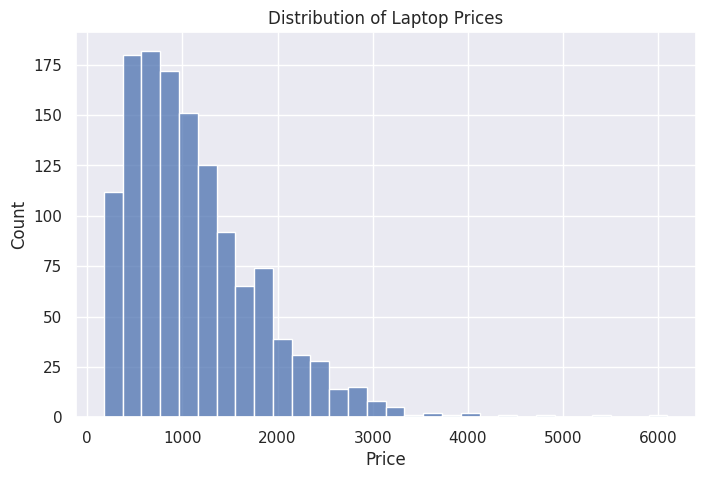

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The distribution is right skewed, meaning that most laptops are in the lower to mid price range, while fewer laptops are very expensive.
This indicates that affordable and mid-range laptops are more common than high end laptops.

## distribution of laptop prices

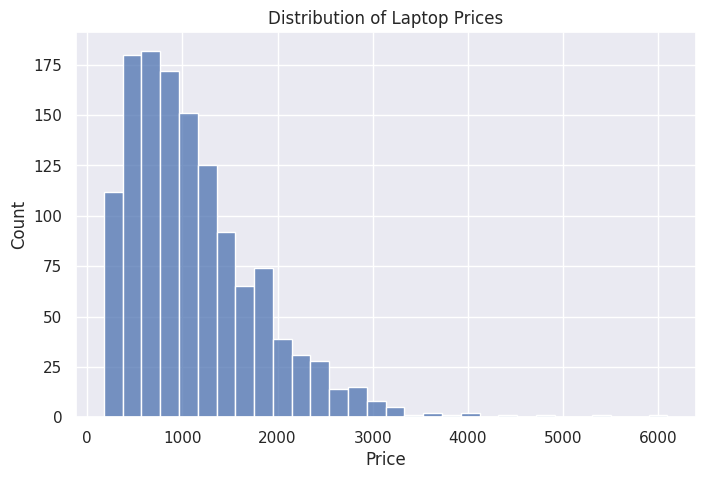

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

- The distribution of laptop prices is right-skewed.
- Most laptops are priced between 500 and 1500 euros.
- There are few high-priced laptops above 3000 euros.
- This indicates that most products are in the mid-range category.


###price vs company

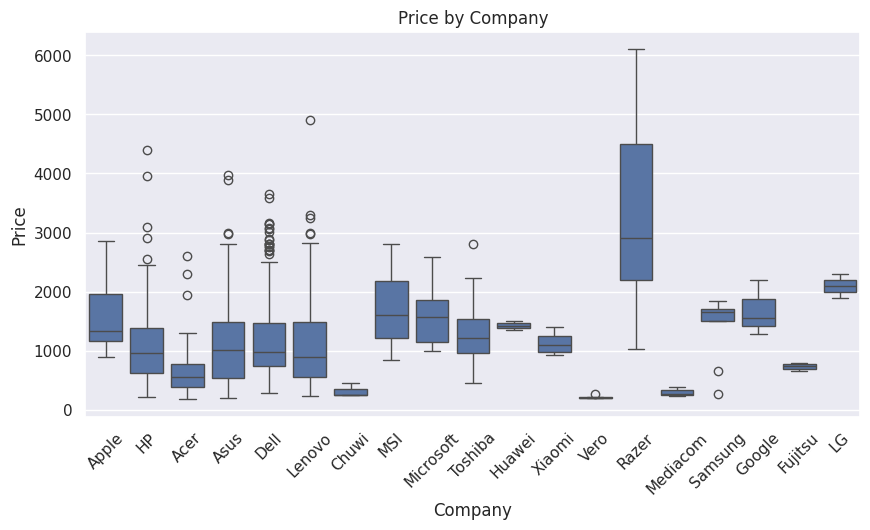

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Company', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Price by Company")
plt.show()

- There is a clear difference in prices between companies.
- Some brands like Razer and Apple tend to have higher prices.
- Other brands offer more budget-friendly options.


### RAM VS price


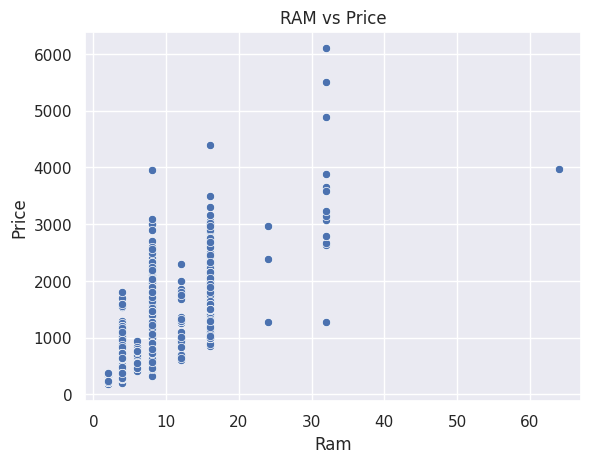

In [26]:
sns.scatterplot(x='Ram', y='Price', data=df)
plt.title("RAM vs Price")
plt.show()


- There is a clear difference in prices between companies.
- Some brands like Razer and Apple tend to have higher prices.
- Other brands offer more budget-friendly options.



### weight vs price

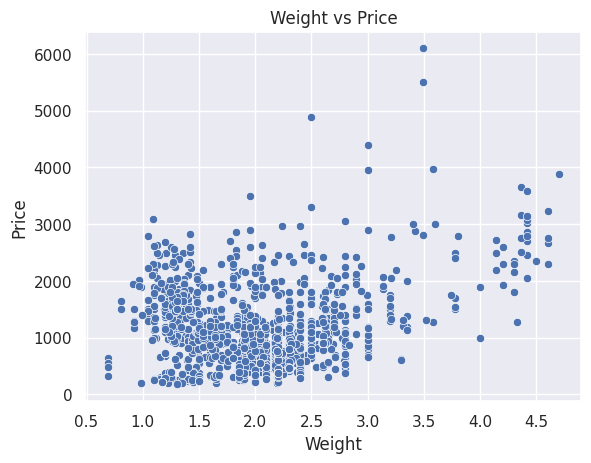

In [27]:
sns.scatterplot(x='Weight', y='Price', data=df)
plt.title("Weight vs Price")
plt.show()

- There is a weak relationship between weight and price.
- Some heavier laptops are expensive, but not always.
- Weight is not a strong factor in determining price.

## screen size vs price

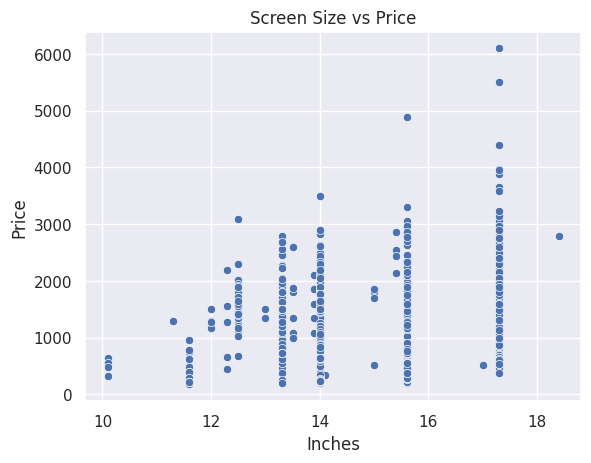

In [29]:
sns.scatterplot(x='Inches', y='Price', data=df)
plt.title("Screen Size vs Price")
plt.show()


- There is a slight positive relationship between screen size and price.
- Larger laptops tend to have higher prices.
- However, the relationship is not very strong as prices vary within the same screen sizes.
- Most laptops are concentrated between 13 and 15 inches.

## price by laptop type

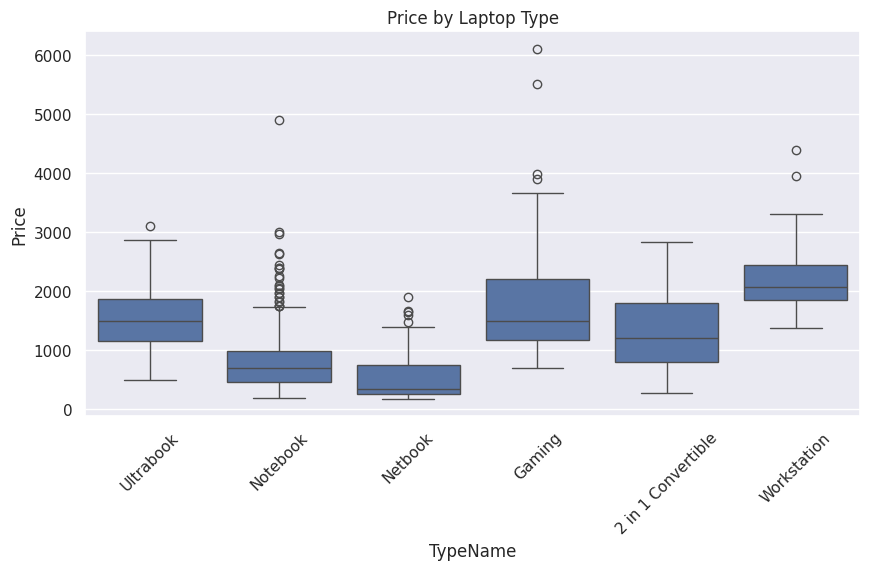

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(x='TypeName', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Price by Laptop Type")
plt.show()

- Gaming laptops tend to have the highest prices due to powerful hardware.
- Workstations are also expensive as they are designed for professional use.
- Ultrabooks and notebooks fall in the mid-price range.
- Netbooks are the cheapest as they have lower specifications.
- There is clear variation in price depending on the laptop type

## price by OS

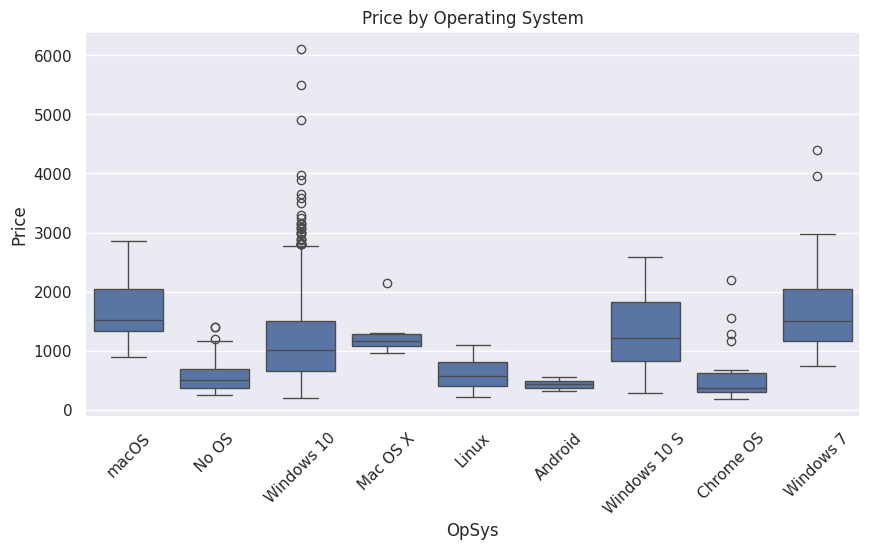

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(x='OpSys', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Price by Operating System")
plt.show()

- macOS laptops tend to have higher prices compared to other operating systems.
- Windows laptops show a wide price range from low to high.
- Chrome OS and No OS devices are generally cheaper.
- Linux and Android laptops are usually in the lower price range.
- The operating system influences the pricing of laptops.

## data cleaning


Before starting the analysis, we checked the dataset to make sure everything is clean and ready to use.

First, we checked for missing values using isna(), and we found that there are no missing values in the dataset.

Then, we checked for duplicate rows using duplicated(), and no duplicates were found.

Some columns like RAM and Weight were written as text (for example: "8GB" and "1.5kg"), so we removed the text part and converted them into numbers to make them easier to analyze.

We also cleaned the column names by removing extra spaces, and we renamed "Price_euros" to "Price" to make it simpler.

Overall, the dataset did not require heavy cleaning, only small adjustments before starting the analysis.